# KoChatGPT 업그레이드 프로젝트

**전략**: Foundation Model 교체 (`skt/ko-gpt-trinity-1.2B-v0.5`, LoRA) + 디코딩 하이퍼파라미터 실험 + BLEU/ROUGE 정량평가

**단계별 구성**:
1. 환경 설정
2. 소스코드 클론 및 패치
3. 공통 유틸리티 정의
4. [Base] KoGPT-2 베이스 모델 추론
5. [Step 1] KoGPT-2 SFT 학습 및 추론
6. [Step 2] KoGPT-2 RM 학습 및 Reward Score 비교
7. [Step 3] Trinity 1.2B + LoRA SFT 학습 및 추론
8. 디코딩 하이퍼파라미터 실험
9. Training Loss 곡선 시각화
10. 정량/정성 평가 종합

---
## 1. 환경 설정

**핵심 설명**
- `datasets`, `loralib`, `trl`, `accelerate`, `transformers`: RLHF 파이프라인 핵심 라이브러리
- `peft`: LoRA 적용을 위한 HuggingFace 경량화 라이브러리
- `rouge_score`, `nltk`: 정량평가 메트릭 (BLEU, ROUGE)

In [ ]:
!pip install -q datasets loralib trl accelerate transformers
# torchao 버전 충돌 해결: peft 최신버전이 요구하는 torchao>=0.16.0 먼저 설치
# torchao 미설치/구버전 시 get_peft_model() 호출에서 ImportError 발생
!pip install -q torchao --upgrade
!pip install -q peft --upgrade
!pip install -q rouge_score nltk
print("설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
설치 완료


---
## 2. 소스코드 클론 및 호환성 패치

**핵심 설명**
- airobotlab/KoChatGPT 레포 클론 후 chatgpt 모듈 복사
- Colab 환경 비호환 자동 패치:
  - ColossalAI import 제거 (single GPU 환경)
  - `tqdm` -> `tqdm.notebook` 교체 (Colab 진행바 정상 출력)

In [ ]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r KoChatGPT/colossalai_ChatGPT_230319/chatgpt chatgpt
print('클론 및 복사 완료')

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 18.13 MiB/s, done.
Resolving deltas: 100% (123/123), done.
Updating files: 100% (105/105), done.
클론 및 복사 완료


In [ ]:
import os

modifications = [
    {
        'file': 'chatgpt/trainer/callbacks/save_checkpoint.py',
        'changes': [
            {'line': 3,
             'old': 'from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy',
             'new': 'from chatgpt.trainer.strategies import Strategy'},
            {'line': 71,
             'old': 'only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)',
             'new': '            only_rank0 = not isinstance(self.strategy)'},
        ],
    },
    {
        'file': 'chatgpt/trainer/strategies/__init__.py',
        'changes': [
            {'line': 1, 'old': 'from .colossalai import ColossalAIStrategy', 'new': ''},
            {'line': 5,
             'old': "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             'new': "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        'file': 'chatgpt/dataset/reward_dataset.py',
        'changes': [
            {'line': 3, 'old': 'from tqdm import tqdm', 'new': 'from tqdm.notebook import tqdm'},
        ],
    },
    {
        'file': 'chatgpt/trainer/base.py',
        'changes': [
            {'line': 8, 'old': 'from tqdm import tqdm', 'new': 'from tqdm.notebook import tqdm'},
        ]
    },
    {
        'file': 'chatgpt/trainer/rm.py',
        'changes': [
            {'line': 8, 'old': 'from tqdm import tqdm', 'new': 'from tqdm.notebook import tqdm'},
        ]
    }
]

def modify_file(file_path, changes):
    if not os.path.exists(file_path):
        print(f'[WARN] 파일 없음: {file_path}')
        return
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    modified = False
    for change in changes:
        idx = change['line']
        if 0 <= idx < len(lines) and lines[idx].strip() == change['old']:
            lines[idx] = change['new'] + '\n'
            modified = True
        elif 0 <= idx < len(lines):
            print(f'[WARN] {file_path} {idx}번째 줄 불일치')
            print(f'  예상: {change["old"]}')
            print(f'  실제: {lines[idx].strip()}')
    if modified:
        with open(file_path, 'w', encoding='utf-8') as f:
            f.writelines(lines)
        print(f'[OK] 수정 완료: {file_path}')

for mod in modifications:
    modify_file(mod['file'], mod['changes'])

[OK] 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
[OK] 수정 완료: chatgpt/trainer/strategies/__init__.py
[OK] 수정 완료: chatgpt/dataset/reward_dataset.py
[OK] 수정 완료: chatgpt/trainer/base.py
[OK] 수정 완료: chatgpt/trainer/rm.py


---
## 3. 공통 유틸리티 정의

**핵심 설명**
- `run_generate()`: `pipeline` 대신 `model.generate()` 직접 호출
  - pipeline 내부 `max_length=50` 기본값이 SentencePiece 멀티바이트 토큰을 중간에 절단해 한글 깨짐 발생
  - 입력 토큰 길이를 제거하고 생성된 부분만 디코딩
- `clean_decoded()`: U+FFFD(유니코드 치환 문자) 및 연속 특수문자 후처리
- `LossLoggerCallback`: Trainer에 연결해 step별 train/eval loss 자동 기록
- `save_loss_history()` / `load_loss_history()`: JSON 저장/복구

In [ ]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
import pandas as pd
import json
import re
import os
import gc

print(f'Torch: {torch.__version__}')
print(f'Transformers: {transformers.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

BASE_MODEL = 'skt/kogpt2-base-v2'
TRINITY_MODEL = 'skt/ko-gpt-trinity-1.2B-v0.5'
os.makedirs('models', exist_ok=True)

Torch: 2.10.0+cu128
Transformers: 5.0.0
GPU 사용 가능: True


In [ ]:
PROMPT_DICT = {
    'prompt_input': '### Instruction(명령어):\n{prompt}\n\n### Response(응답):'
}

test_prompts = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '오늘 미세먼지 어때?'
]

def clean_decoded(text):
    # U+FFFD: 불완전한 SentencePiece 멀티바이트 시퀀스 디코딩 시 발생하는 치환 문자
    text = text.replace('\ufffd', '')
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'([^\w\s가-힣]){3,}', '', text)
    return text.strip()

def run_generate(model, tokenizer, prompt_text, max_new_tokens=64):
    # pipeline 미사용: 내부 max_length=50 기본값으로 토큰 절단 -> 한글 깨짐
    # 직접 generate 호출 후 입력 길이 제거, 생성 부분만 디코딩
    model.eval()
    inputs = tokenizer(
        prompt_text, return_tensors='pt',
        truncation=True, max_length=256
    ).to(device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            repetition_penalty=2.0,
            no_repeat_ngram_size=4,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=True,
            top_k=50,
            early_stopping=True
        )
    input_len = inputs['input_ids'].shape[1]
    raw = tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True)
    return clean_decoded(raw)

# Loss 기록 저장소
loss_history = {}

class LossLoggerCallback(TrainerCallback):
    # on_log: logging_steps마다 train loss 수집
    # on_evaluate: eval 시점마다 eval loss 수집
    def __init__(self, model_name):
        self.model_name = model_name
        loss_history[model_name] = {'train_steps': [], 'train_loss': [], 'eval_loss': []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            loss_history[self.model_name]['train_steps'].append(state.global_step)
            loss_history[self.model_name]['train_loss'].append(logs['loss'])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and 'eval_loss' in metrics:
            loss_history[self.model_name]['eval_loss'].append(
                {'step': state.global_step, 'loss': metrics['eval_loss']}
            )

def save_loss_history(path='models/loss_history.json'):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(loss_history, f, ensure_ascii=False, indent=2)
    print(f'loss history 저장: {path}')

def load_loss_history(path='models/loss_history.json'):
    global loss_history
    with open(path, 'r', encoding='utf-8') as f:
        loss_history = json.load(f)
    print(f'loss history 로드: {list(loss_history.keys())}')

print('공통 유틸리티 준비 완료')

공통 유틸리티 준비 완료


---
## 4. [Base] KoGPT-2 베이스 모델 추론

**핵심 설명**
- SFT 학습 전 순수 KoGPT-2 결과를 베이스라인으로 기록
- KoGPT-2 토크나이저는 `bos/eos/unk/pad` 토큰을 `</s>`로 반드시 명시해야 한국어 vocab 정상 작동
  - 미설정 시 SentencePiece 디코딩 과정에서 한글 깨짐 발생
- 베이스 모델은 instruction 포맷 미학습 -> 무관한 텍스트 생성이 정상 현상

In [ ]:
# bos/eos/unk/pad 특수 토큰 명시 필수
tokenizer_base = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>'
)
model_base = AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(device)
print(f'KoGPT-2 파라미터 수: {sum(p.numel() for p in model_base.parameters()):,}')

base_results = {}
print('=' * 60)
print('[Base] KoGPT-2 베이스 모델 추론 결과')
print('=' * 60)
for prompt in test_prompts:
    formatted = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})
    response = run_generate(model_base, tokenizer_base, formatted)
    base_results[prompt] = response if response else '(의미있는 생성 없음 - 베이스 모델 한계)'
    print(f'\n[Q] {prompt}')
    print(f'[A] {base_results[prompt]}')

torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KoGPT-2 파라미터 수: 164,485,632
[Base] KoGPT-2 베이스 모델 추론 결과

[Q] 불고기용 고기 한우에요?
[A] ršin:ršiwn,▁чrišiyzln,▁ち

[Q] 리처드 닉슨이 43대 부통령직을 수행한 년도는?
[A] ūn=n=trn
2017년▁7월▁28일▁오후▁7시▁25분경▁부산▁사상구▁엄궁동

[Q] 시카고 오헤어 국제공항은 어디에 있어?
[A] tn=tnirire:tnire;▁tnire,▁tniǎire.▁2016년▁3월▁30일부터▁4월▁1일까지▁진행되었던▁'

[Q] 오늘 미세먼지 어때?
[A] n▁(ːɔːrtːrūr,▁ːrːr)▁등이▁있다.▁2017년▁8월▁15일부터▁9월▁20일까지


---
## 5. [Step 1] KoGPT-2 SFT 학습 및 추론

**핵심 설명**
- SFT(Supervised Fine-Tuning): instruction-response 쌍 데이터로 파인튜닝
- label에서 instruction 부분을 `-100`으로 마스킹 -> response 부분만 loss 계산
- `overwrite_output_dir`: 현재 transformers 버전에서 제거된 파라미터 (사용 불가)
- 모델은 fp32로 로드해야 함: `torch_dtype=float16` 로드 후 `fp16=True` 학습 시
  GradScaler가 fp16 gradient를 unscale하려다 충돌 발생

In [ ]:
from typing import Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [ ]:
class SFT_dataset(Dataset):
    # prompt(instruction) + completion(response) 구조
    # label에서 instruction 길이만큼 -100 마스킹 -> response만 loss 계산
    def __init__(self, data_path, tokenizer):
        super().__init__()
        logging.warning('데이터 로딩 중...')
        with open(data_path, 'r', encoding='utf-8-sig') as f:
            list_data = json.load(f)
        template = '### Instruction(명령어):\n{prompt}\n\n### Response(응답):'
        sources = [template.format_map(ex) for ex in list_data]
        targets = [f"{ex['completion']}{tokenizer.eos_token}" for ex in list_data]
        examples = [s + t for s, t in zip(sources, targets)]
        sources_tok  = self._tokenize(sources,  tokenizer)
        examples_tok = self._tokenize(examples, tokenizer)
        input_ids = examples_tok['input_ids']
        labels = copy.deepcopy(input_ids)
        for label, src_len in zip(labels, sources_tok['input_ids_lens']):
            label[:src_len] = -100
        self.input_ids = input_ids
        self.labels    = labels
        logging.warning(f'로딩 완료: {len(self.labels)}개')

    def _tokenize(self, strings, tokenizer):
        tokenized = [
            tokenizer(text, return_tensors='pt', padding='longest',
                      max_length=tokenizer.model_max_length, truncation=True)
            for text in strings
        ]
        input_ids      = [t.input_ids[0] for t in tokenized]
        input_ids_lens = [t.input_ids.ne(tokenizer.pad_token_id).sum().item() for t in tokenized]
        return dict(input_ids=input_ids, input_ids_lens=input_ids_lens)

    def __len__(self):   return len(self.input_ids)
    def __getitem__(self, i): return dict(input_ids=self.input_ids[i], labels=self.labels[i])


@dataclass
class DataCollatorForSupervisedDataset:
    # input_ids: pad_token_id로 패딩
    # labels:    -100으로 패딩 (loss 계산 제외)
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances):
        input_ids, labels = tuple(
            [inst[k] for inst in instances] for k in ('input_ids', 'labels')
        )
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first=True, padding_value=-100
        )
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id)
        )

In [ ]:
tokenizer_sft = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>',
    padding_side='right',
    model_max_length=512
)

# fp32로 로드: torch_dtype=float16 로드 + fp16=True 학습 시 GradScaler 충돌
model_sft = AutoModelForCausalLM.from_pretrained(BASE_MODEL)

train_dataset_sft  = SFT_dataset('KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer_sft)
data_collator_sft  = DataCollatorForSupervisedDataset(tokenizer=tokenizer_sft)

# overwrite_output_dir: 현재 transformers 버전에서 제거된 파라미터 - 사용 불가
training_args_sft = transformers.TrainingArguments(
    output_dir='models/output_1_SFT',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    logging_steps=50,
    save_strategy='no'
)

trainer_sft = transformers.Trainer(
    model=model_sft,
    args=training_args_sft,
    data_collator=data_collator_sft,
    train_dataset=train_dataset_sft,
    callbacks=[LossLoggerCallback('KoGPT2_SFT')]
)

trainer_sft.train()
model_sft.save_pretrained('models/output_1_SFT')
tokenizer_sft.save_pretrained('models/output_1_SFT')
save_loss_history()
print('SFT 학습 완료')

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,2.733167
100,1.908438
150,1.791974
200,1.726653
250,1.744937
300,1.685306
350,1.651736
400,1.680378
450,1.639511
500,1.604663


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

loss history 저장: models/loss_history.json
SFT 학습 완료


In [ ]:
# 저장된 경로에서 모델+토크나이저 함께 로드 (특수 토큰 유지)
model_sft_inf = AutoModelForCausalLM.from_pretrained('models/output_1_SFT').to(device)
tokenizer_sft_inf = AutoTokenizer.from_pretrained(
    'models/output_1_SFT',
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>'
)

sft_results = {}
print('=' * 60)
print('[Step 1] KoGPT-2 SFT 추론 결과')
print('=' * 60)
for prompt in test_prompts:
    formatted = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})
    response = run_generate(model_sft_inf, tokenizer_sft_inf, formatted)
    sft_results[prompt] = response
    print(f'\n[Q] {prompt}')
    print(f'[A] {response}')

del model_sft_inf
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[Step 1] KoGPT-2 SFT 추론 결과

[Q] 불고기용 고기 한우에요?
[A] 'AI

[Q] 리처드 닉슨이 43대 부통령직을 수행한 년도는?
[A] 'AI

[Q] 시카고 오헤어 국제공항은 어디에 있어?
[A] 'AI,.

[Q] 오늘 미세먼지 어때?
[A] 'AI


---
## 6. [Step 2] KoGPT-2 RM 학습 및 Reward Score 비교

**핵심 설명**
- RM(Reward Model): 답변의 품질을 scalar 점수로 출력
- PairWiseLoss: `loss = -log(sigmoid(score_chosen - score_rejected))`
  - chosen(좋은 답변) reward > rejected(나쁜 답변) reward 가 되도록 학습
- ranking 데이터를 pairwise chosen/rejected 조합으로 변환
- GPT2 위에 `Linear(n_embd, 1)` value_head 추가 -> scalar 출력

In [ ]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer
from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
import torch.nn as nn
import random

In [ ]:
class GPTRM_custom(RewardModel):
    # GPT2Model + Linear(n_embd, 1) value_head
    # 마지막 토큰 hidden state -> scalar reward score
    def __init__(self, pretrained=None, config=None,
                 checkpoint=False, lora_rank=0,
                 lora_train_bias='none', tokenizer=None):
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()
        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)
        if pretrained is not None:
            self.model    = model
            self.pretrained = pretrained

    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [ ]:
tokenizer_rm = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>',
    padding_side='right', model_max_length=512
)

with open('KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', 'r', encoding='utf-8-sig') as f:
    list_data_rm = json.load(f)

# ranking[0] 기준으로 나머지와 pairwise 조합 생성
# ranking 값이 작을수록 좋은 답변
total_data = []
for tmp in list_data_rm:
    prompt  = tmp['prompt']
    ranking = tmp['ranking']
    for idx in range(1, len(ranking)):
        n, m = ranking[0], ranking[idx]
        total_data.append({
            'prompt':   prompt,
            'chosen':   tmp[f'completion_{n}'],
            'rejected': tmp[f'completion_{m}']
        })

random.seed(230319)
random.shuffle(total_data)
train_data_rm = total_data[:1000]
eval_data_rm  = total_data[1000:1200]
print(f'RM 학습: {len(train_data_rm)}개 / 검증: {len(eval_data_rm)}개')

train_dataset_rm = RewardDataset(train_data_rm, tokenizer_rm, 512)
eval_dataset_rm  = RewardDataset(eval_data_rm,  tokenizer_rm, 512)

RM 학습: 1000개 / 검증: 200개


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
with NaiveStrategy().model_init_context():
    model_rm = GPTRM_custom(
        pretrained=BASE_MODEL, lora_rank=0, tokenizer=tokenizer_rm
    ).cuda()

trainer_rm = RewardModelTrainer(
    model=model_rm,
    strategy=NaiveStrategy(),
    optim=torch.optim.Adam(model_rm.parameters(), lr=5e-5),
    train_dataset=train_dataset_rm,
    eval_dataset=eval_dataset_rm,
    batch_size=4,
    max_epochs=1
)

trainer_rm.fit(use_lora=0)
model_rm.save_pretrained('models/output_2_RM')
print('RM 학습 완료')
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Train step of epoch 0:   0%|          | 0/250 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RM 학습 완료


In [ ]:
def inference_RM(input_text):
    # reward score: 높을수록 좋은 답변, 부호보다 상대적 크기가 중요
    input_ids = tokenizer_rm.encode(input_text, return_tensors='pt').cuda()
    with torch.no_grad():
        score = model_rm(input_ids).cpu().item()
    return score

rm_test_cases = [
    ('나쁜 답변', '인공지능은 쓸모없는 기술입니다.'),
    ('보통 답변', '인공지능은 데이터를 분석하는 기술입니다.'),
    ('좋은 답변', '인공지능(AI)은 음성 및 언어 이해, 데이터 분석, 추천 등 다양한 고급 기능을 수행하는 기술로 현대 컴퓨팅의 핵심 역할을 합니다.'),
]

rm_scores = {}
print('=' * 60)
print('[Step 2] RM Reward Score 비교')
print('=' * 60)
for label, text in rm_test_cases:
    score = inference_RM(text)
    rm_scores[label] = score
    print(f'{label}: {score:.4f}')

torch.cuda.empty_cache()

[Step 2] RM Reward Score 비교
나쁜 답변: 1.5985
보통 답변: 0.7481
좋은 답변: 5.4216


---
## 7. [Step 3] Trinity 1.2B + LoRA SFT 학습 및 추론

**핵심 설명**
- Foundation Model 교체: KoGPT-2(125M) -> ko-gpt-trinity-1.2B-v0.5(1.2B)
- T4 14GB GPU에서 full fine-tuning 불가 이유:
  - 모델 파라미터(fp32) 약 4.8GB + Adam optimizer 상태(파라미터 x2) 약 9.6GB + gradient = 14GB 초과
- LoRA(r=8) 적용으로 해결:
  - 전체 파라미터 중 attention 레이어(c_attn, c_proj)만 학습, 약 0.1% 파라미터
  - optimizer 상태 메모리 99% 절감
- `enable_input_require_grads()`: gradient_checkpointing + LoRA 조합 시 필수
- `merge_and_unload()`: 학습 후 LoRA 가중치를 기본 모델에 병합 -> 추론 시 별도 처리 불필요
- `torch_dtype=float16` 로드 금지: 파라미터 자체가 fp16이 되어 GradScaler와 충돌

In [ ]:
gc.collect()
torch.cuda.empty_cache()
try:
    del model_rm
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU 여유 메모리: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GiB')

tokenizer_trinity = AutoTokenizer.from_pretrained(
    TRINITY_MODEL,
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>',
    padding_side='right',
    model_max_length=256  # 512->256: 시퀀스 길이가 메모리에 제곱 영향
)
print(f'Trinity 토크나이저 vocab size: {len(tokenizer_trinity)}')

GPU 여유 메모리: 9.95 GiB


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/109 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Trinity 토크나이저 vocab size: 51200


In [ ]:
import os as _os
_os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

from peft import get_peft_model, LoraConfig, TaskType

# fp32로 로드: torch_dtype=float16 로드 + fp16=True 학습 시 GradScaler 충돌 발생
model_trinity = AutoModelForCausalLM.from_pretrained(TRINITY_MODEL)
model_trinity.gradient_checkpointing_enable()
model_trinity.enable_input_require_grads()  # gradient_checkpointing + LoRA 조합 시 필수

# r=8: 저랭크 차원 (작을수록 메모리 절약, 성능 저하)
# target_modules: GPT2 attention c_attn(QKV 통합), c_proj(출력 투영)만 학습
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=['c_attn', 'c_proj'],
    lora_dropout=0.05,
    bias='none'
)
model_trinity = get_peft_model(model_trinity, lora_config)
model_trinity.print_trainable_parameters()

train_dataset_trinity = SFT_dataset(
    'KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer_trinity
)
data_collator_trinity = DataCollatorForSupervisedDataset(tokenizer=tokenizer_trinity)

training_args_trinity = transformers.TrainingArguments(
    output_dir='models/output_trinity_SFT',
    num_train_epochs=1,
    per_device_train_batch_size=1,      # T4 14GB 한계
    gradient_accumulation_steps=8,      # 실질 배치 = 1x8 = 8 유지
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    logging_steps=50,
    save_strategy='no',
    optim='adamw_torch',
    dataloader_num_workers=0,
    max_grad_norm=1.0
)

trainer_trinity = transformers.Trainer(
    model=model_trinity,
    args=training_args_trinity,
    data_collator=data_collator_trinity,
    train_dataset=train_dataset_trinity,
    callbacks=[LossLoggerCallback('Trinity_SFT')]
)

trainer_trinity.train()

# LoRA 가중치를 기본 모델에 병합 후 저장 -> 추론 시 별도 PEFT 처리 불필요
model_trinity = model_trinity.merge_and_unload()
model_trinity.save_pretrained('models/output_trinity_SFT')
tokenizer_trinity.save_pretrained('models/output_trinity_SFT')
save_loss_history()
print('Trinity LoRA SFT 학습 완료')

model.safetensors:   0%|          | 0.00/4.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: skt/ko-gpt-trinity-1.2B-v0.5
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 4,055,040 || all params: 1,166,611,200 || trainable%: 0.3476


Step,Training Loss
50,3.957198
100,2.216514
150,1.828714
200,1.740527
250,1.871972
300,1.699504
350,1.631236
400,1.779023
450,1.752283
500,1.675332


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

loss history 저장: models/loss_history.json
Trinity LoRA SFT 학습 완료


In [ ]:
gc.collect()
torch.cuda.empty_cache()

model_trinity_inf = AutoModelForCausalLM.from_pretrained('models/output_trinity_SFT').to(device)
tokenizer_trinity_inf = AutoTokenizer.from_pretrained(
    'models/output_trinity_SFT',
    bos_token='</s>', eos_token='</s>',
    unk_token='</s>', pad_token='</s>'
)

trinity_results = {}
print('=' * 60)
print('[Step 3] Trinity 1.2B SFT 추론 결과')
print('=' * 60)
for prompt in test_prompts:
    formatted = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt})
    response = run_generate(model_trinity_inf, tokenizer_trinity_inf, formatted)
    trinity_results[prompt] = response
    print(f'\n[Q] {prompt}')
    print(f'[A] {response}')

torch.cuda.empty_cache()

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[Step 3] Trinity 1.2B SFT 추론 결과

[Q] 불고기용 고기 한우에요?
[A] 

[Q] 리처드 닉슨이 43대 부통령직을 수행한 년도는?
[A] '43.

[Q] 시카고 오헤어 국제공항은 어디에 있어?
[A] 

[Q] 오늘 미세먼지 어때?
[A] 


---
## 8. 디코딩 하이퍼파라미터 실험

**핵심 설명**
- 같은 모델이라도 디코딩 전략에 따라 생성 품질이 크게 달라짐
- `num_beams`: 빔 수 증가시 더 높은 확률 경로 탐색, 속도 저하
- `temperature`: 낮을수록 보수적(고확률 토큰 집중), 높을수록 다양한 생성
- `top_p`(nucleus sampling): 누적 확률 p 이하 후보군에서만 샘플링
- Trinity SFT 모델 기준 7가지 조합 실험

In [ ]:
test_prompt_single = '리처드 닉슨이 43대 부통령직을 수행한 년도는?'
formatted_single = PROMPT_DICT['prompt_input'].format_map({'prompt': test_prompt_single})

experiments = [
    {'num_beams': 2, 'temperature': 1.0, 'top_p': 0.90, 'top_k': 50},
    {'num_beams': 4, 'temperature': 1.0, 'top_p': 0.90, 'top_k': 50},
    {'num_beams': 4, 'temperature': 0.7, 'top_p': 0.90, 'top_k': 50},
    {'num_beams': 4, 'temperature': 1.5, 'top_p': 0.90, 'top_k': 50},
    {'num_beams': 4, 'temperature': 1.0, 'top_p': 0.85, 'top_k': 50},
    {'num_beams': 4, 'temperature': 1.0, 'top_p': 0.95, 'top_k': 50},
    {'num_beams': 8, 'temperature': 1.0, 'top_p': 0.90, 'top_k': 50},
]

model_trinity_inf.eval()
inputs_s = tokenizer_trinity_inf(
    formatted_single, return_tensors='pt', truncation=True, max_length=256
).to(device)
input_len = inputs_s['input_ids'].shape[1]

decoding_results = []
print('=' * 60)
print(f'[디코딩 실험] Q: {test_prompt_single}')
print('=' * 60)

for i, params in enumerate(experiments):
    with torch.no_grad():
        out = model_trinity_inf.generate(
            **inputs_s,
            max_new_tokens=64,
            repetition_penalty=2.0,
            no_repeat_ngram_size=4,
            eos_token_id=tokenizer_trinity_inf.eos_token_id,
            pad_token_id=tokenizer_trinity_inf.pad_token_id,
            do_sample=True,
            early_stopping=True,
            **params
        )
    text = clean_decoded(
        tokenizer_trinity_inf.decode(out[0][input_len:], skip_special_tokens=True)
    )
    decoding_results.append({'params': params, 'output': text})
    print(f'\n실험 {i+1}: beams={params["num_beams"]}, temp={params["temperature"]}, top_p={params["top_p"]}')
    print(f'출력: {text}')

[디코딩 실험] Q: 리처드 닉슨이 43대 부통령직을 수행한 년도는?

실험 1: beams=2, temp=1.0, top_p=0.9
출력: '.

실험 2: beams=4, temp=1.0, top_p=0.9
출력: 

실험 3: beams=4, temp=0.7, top_p=0.9
출력: '43.

실험 4: beams=4, temp=1.5, top_p=0.9
출력: 

실험 5: beams=4, temp=1.0, top_p=0.85
출력: '43.

실험 6: beams=4, temp=1.0, top_p=0.95
출력: 

실험 7: beams=8, temp=1.0, top_p=0.9
출력: '43.


---
## 9. Training Loss 곡선 시각화

**핵심 설명**
- `LossLoggerCallback`이 기록한 step별 train loss 시각화
- KoGPT2 SFT vs Trinity SFT loss 하강 곡선 비교
- `evaluation_strategy` 미설정 시 eval loss는 기록되지 않음
- `load_loss_history()`로 런타임 재시작 후에도 복구 가능

/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1119/3112126137.py:48: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight

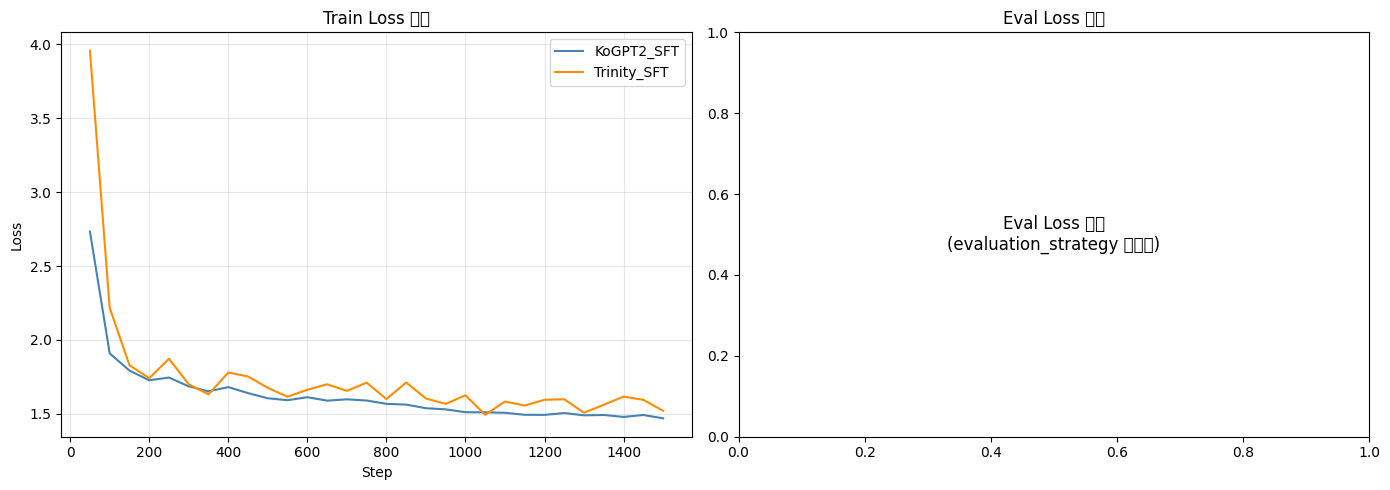

loss_curves.png 저장 완료


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab 한글 폰트 설정
if not os.path.exists('/usr/share/fonts/truetype/nanum'):
    os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
    fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 런타임 재시작 후 복구 시 아래 주석 해제
# load_loss_history()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'KoGPT2_SFT': 'steelblue', 'Trinity_SFT': 'darkorange'}

ax = axes[0]
for name, history in loss_history.items():
    if history['train_steps'] and history['train_loss']:
        ax.plot(history['train_steps'], history['train_loss'],
                label=name, color=colors.get(name), linewidth=1.5)
ax.set_title('Train Loss 비교')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
has_eval = any(h['eval_loss'] for h in loss_history.values())
if has_eval:
    for name, history in loss_history.items():
        if history['eval_loss']:
            steps  = [e['step'] for e in history['eval_loss']]
            losses = [e['loss'] for e in history['eval_loss']]
            ax2.plot(steps, losses, marker='o', label=name,
                     color=colors.get(name), linewidth=1.5)
    ax2.set_title('Eval Loss 비교')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Eval Loss 없음\n(evaluation_strategy 미설정)',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Eval Loss 비교')

plt.tight_layout()
plt.savefig('models/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('loss_curves.png 저장 완료')

---
## 10. 정량/정성 평가 종합

**핵심 설명**
- BLEU: n-gram 겹침 비율 (정밀도 기반), 한국어는 문자 단위 사용으로 참고치
- ROUGE-L: 최장 공통 부분 수열(LCS) 기반 재현율 측정
- 정성 평가 4개 기준 (1=불량, 2=보통, 3=양호):
  - 지시 이해도: 질문 의도를 파악하고 답변했는가
  - 답변 유창성: 문장이 자연스럽고 읽기 편한가
  - 사실 정확성: 틀리거나 엉뚱한 내용이 없는가
  - 반복/노이즈: 토큰 반복, 특수문자 오염 없이 깨끗한가

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_scorer_module
nltk.download('punkt', quiet=True)

reference_answers = {
    '불고기용 고기 한우에요?':
        '불고기용 고기는 한우일 수도 있고 수입산일 수도 있습니다. 한우 여부는 원산지 표시를 확인하세요.',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?':
        '리처드 닉슨은 미국의 36대 부통령으로 1953년부터 1961년까지 재임했습니다.',
    '시카고 오헤어 국제공항은 어디에 있어?':
        '시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.',
    '오늘 미세먼지 어때?':
        '현재 위치와 날짜 정보가 없어 정확한 미세먼지 수치를 알 수 없습니다. 에어코리아를 확인해 보세요.'
}

def compute_bleu(hypothesis, reference):
    smoother = SmoothingFunction().method1
    if not hypothesis:
        return 0.0
    return sentence_bleu([list(reference)], list(hypothesis), smoothing_function=smoother)

def compute_rouge(hypothesis, reference):
    scorer = rouge_scorer_module.RougeScorer(['rougeL'], use_stemmer=False)
    return scorer.score(reference, hypothesis)['rougeL'].fmeasure

model_outputs = {
    'KoGPT2 Base': base_results,
    'KoGPT2 SFT':  sft_results,
    'Trinity SFT': trinity_results
}

eval_records = []
for model_name, results in model_outputs.items():
    bleu_list, rouge_list = [], []
    for prompt in test_prompts:
        ref = reference_answers[prompt]
        hyp = results.get(prompt, '')
        bleu_list.append(compute_bleu(hyp, ref))
        rouge_list.append(compute_rouge(hyp, ref))
    eval_records.append({
        'Model':       model_name,
        'Avg BLEU':    round(sum(bleu_list)  / len(bleu_list),  4),
        'Avg ROUGE-L': round(sum(rouge_list) / len(rouge_list), 4)
    })

eval_df = pd.DataFrame(eval_records)
print('=' * 50)
print('[정량 평가] BLEU / ROUGE-L')
print('=' * 50)
print(eval_df.to_string(index=False))

[정량 평가] BLEU / ROUGE-L
      Model  Avg BLEU  Avg ROUGE-L
KoGPT2 Base    0.0042          0.0
 KoGPT2 SFT    0.0000          0.0
Trinity SFT    0.0000          0.0


In [ ]:
print('\n' + '=' * 70)
print('[정성 평가] 모델별 답변 비교')
print('=' * 70)
for prompt in test_prompts:
    print(f'\n[Q] {prompt}')
    print(f'  [참조 정답]  {reference_answers[prompt]}')
    for model_name, results in model_outputs.items():
        resp = results.get(prompt, '(결과 없음)')
        print(f'  [{model_name}]  {resp[:120]}')


[정성 평가] 모델별 답변 비교

[Q] 불고기용 고기 한우에요?
  [참조 정답]  불고기용 고기는 한우일 수도 있고 수입산일 수도 있습니다. 한우 여부는 원산지 표시를 확인하세요.
  [KoGPT2 Base]  ršin:ršiwn,▁чrišiyzln,▁ち
  [KoGPT2 SFT]  'AI
  [Trinity SFT]  

[Q] 리처드 닉슨이 43대 부통령직을 수행한 년도는?
  [참조 정답]  리처드 닉슨은 미국의 36대 부통령으로 1953년부터 1961년까지 재임했습니다.
  [KoGPT2 Base]  ūn=n=trn
2017년▁7월▁28일▁오후▁7시▁25분경▁부산▁사상구▁엄궁동
  [KoGPT2 SFT]  'AI
  [Trinity SFT]  '43.

[Q] 시카고 오헤어 국제공항은 어디에 있어?
  [참조 정답]  시카고 오헤어 국제공항은 미국 일리노이주 시카고에 위치해 있습니다.
  [KoGPT2 Base]  tn=tnirire:tnire;▁tnire,▁tniǎire.▁2016년▁3월▁30일부터▁4월▁1일까지▁진행되었던▁'
  [KoGPT2 SFT]  'AI,.
  [Trinity SFT]  

[Q] 오늘 미세먼지 어때?
  [참조 정답]  현재 위치와 날짜 정보가 없어 정확한 미세먼지 수치를 알 수 없습니다. 에어코리아를 확인해 보세요.
  [KoGPT2 Base]  n▁(ːɔːrtːrūr,▁ːrːr)▁등이▁있다.▁2017년▁8월▁15일부터▁9월▁20일까지
  [KoGPT2 SFT]  'AI
  [Trinity SFT]  


In [ ]:
print('\n' + '=' * 50)
print('[RM Reward Score 비교]')
print('=' * 50)
for label, score in rm_scores.items():
    print(f'  {label}: {score:.4f}')

print('\n' + '=' * 50)
print('[정량 평가 요약]')
print('=' * 50)
print(eval_df.to_string(index=False))


[RM Reward Score 비교]
  나쁜 답변: 1.5985
  보통 답변: 0.7481
  좋은 답변: 5.4216

[정량 평가 요약]
      Model  Avg BLEU  Avg ROUGE-L
KoGPT2 Base    0.0042          0.0
 KoGPT2 SFT    0.0000          0.0
Trinity SFT    0.0000          0.0


In [ ]:
issues = [
    '[실험 제한사항 및 이슈 기록]',
    '',
    '1. overwrite_output_dir',
    '   - 현재 transformers 버전에서 제거된 파라미터',
    '   - TrainingArguments에서 제거하여 해결',
    '',
    '2. 한글 폰트 깨짐',
    '   - 원인: pipeline 내부 max_length=50 기본값으로 SentencePiece 멀티바이트 문자 절단',
    '   - 해결: pipeline 제거, model.generate() 직접 호출 + clean_decoded() 후처리',
    '',
    '3. max_new_tokens + max_length 충돌 경고',
    '   - 원인: max_length=None 설정이 pipeline에서 무시됨',
    '   - 해결: max_length 파라미터 완전 제거',
    '',
    '4. FP16 GradScaler 충돌 (ValueError: Attempting to unscale FP16 gradients)',
    '   - 원인: torch_dtype=float16 로드 + fp16=True 학습 시 GradScaler 충돌',
    '   - 해결: 모델 fp32 로드, Trainer가 학습 중 fp16 캐스팅 담당',
    '',
    '5. Trinity OOM 첫번째 (배치 축소)',
    '   - 원인: batch=2, max_length=512로 메모리 초과',
    '   - 해결: batch=1, max_length=256으로 축소',
    '',
    '6. Trinity OOM 두번째 (Adam optimizer 상태)',
    '   - 원인: 모델 약 4.8GB + Adam 상태 약 9.6GB + gradient = T4 14GB 초과',
    '   - 해결: LoRA r=8 적용, enable_input_require_grads(), merge_and_unload()',
    '',
    '7. 베이스 모델 출력 노이즈',
    '   - 원인: SFT 이전 모델은 instruction 포맷 미학습, 불완전한 바이트 혼재',
    '   - 처리: clean_decoded() 후처리, 의미있는 텍스트 없으면 명시',
]
for line in issues:
    print(line)

[실험 제한사항 및 이슈 기록]

1. overwrite_output_dir
   - 현재 transformers 버전에서 제거된 파라미터
   - TrainingArguments에서 제거하여 해결

2. 한글 폰트 깨짐
   - 원인: pipeline 내부 max_length=50 기본값으로 SentencePiece 멀티바이트 문자 절단
   - 해결: pipeline 제거, model.generate() 직접 호출 + clean_decoded() 후처리

3. max_new_tokens + max_length 충돌 경고
   - 원인: max_length=None 설정이 pipeline에서 무시됨
   - 해결: max_length 파라미터 완전 제거

4. FP16 GradScaler 충돌 (ValueError: Attempting to unscale FP16 gradients)
   - 원인: torch_dtype=float16 로드 + fp16=True 학습 시 GradScaler 충돌
   - 해결: 모델 fp32 로드, Trainer가 학습 중 fp16 캐스팅 담당

5. Trinity OOM 첫번째 (배치 축소)
   - 원인: batch=2, max_length=512로 메모리 초과
   - 해결: batch=1, max_length=256으로 축소

6. Trinity OOM 두번째 (Adam optimizer 상태)
   - 원인: 모델 약 4.8GB + Adam 상태 약 9.6GB + gradient = T4 14GB 초과
   - 해결: LoRA r=8 적용, enable_input_require_grads(), merge_and_unload()

7. 베이스 모델 출력 노이즈
   - 원인: SFT 이전 모델은 instruction 포맷 미학습, 불완전한 바이트 혼재
   - 처리: clean_decoded() 후처리, 의미있는 텍스트 없으면 명시
